In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv("Zomato-data-.csv")
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [3]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [5]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
rate_s=df["rate"].str.split("/").str[0]
df1=df.copy()
df1["rate"]=rate_s
df1["rate"]=pd.to_numeric(df1["rate"])
df1.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [9]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


# Online VS Offline Order

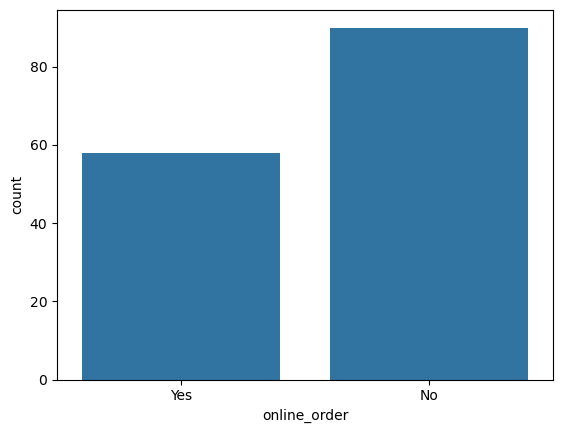

In [10]:
sns.countplot(x=df1["online_order"])
plt.show()

### Conclusion: 
**The majority of the restaurants do not accept online orders**

# Restaurant Types

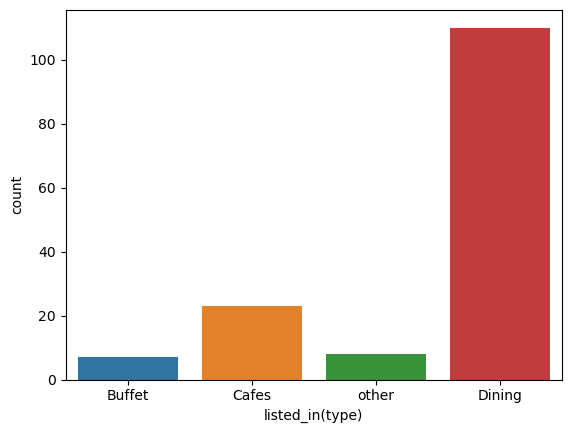

In [11]:
sns.countplot(x=df1["listed_in(type)"],hue=df1['listed_in(type)'])
plt.show()

### Conclusion:
**The majority of the restaurants fall in Dining category**

# Votes by Restaurant Type

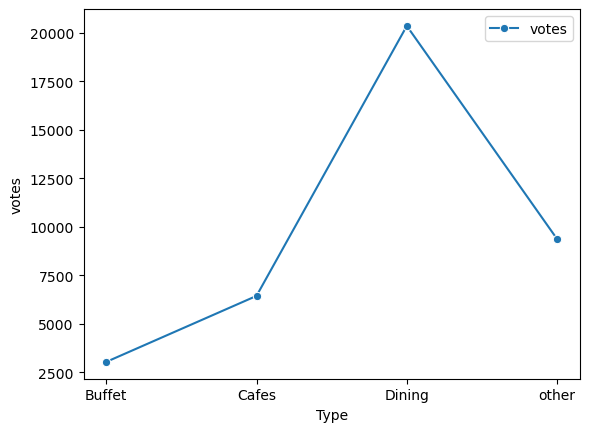

In [12]:
grouped_vote=df1["votes"].groupby(df1["listed_in(type)"]).sum()
df_g=pd.DataFrame({"votes": grouped_vote})
sns.lineplot(df_g, marker='o')
plt.xlabel("Type")
plt.ylabel("votes")
plt.show()

### Conclusion:
**The majority of prefer Dining restaurants**

# Top 5 Restaurent

In [13]:
data_g=df1[["name","rate","votes"]].copy()
data_g.drop_duplicates(inplace=True)
data_g["weighted_rating"]=data_g["rate"]*data_g["votes"]
Top5=data_g.nlargest(5,"weighted_rating").reset_index(drop=True)
Top5=Top5.sort_values(by="weighted_rating",ascending=False)
Top5.head()

,name,rate,votes,weighted_rating
0,Empire Restaurant,4.4,4884,21489.6
1,Meghana Foods,4.4,4401,19364.4
2,Onesta,4.6,2556,11757.6
3,Kabab Magic,4.1,1720,7052.0
4,Szechuan Dragon,4.2,1647,6917.4


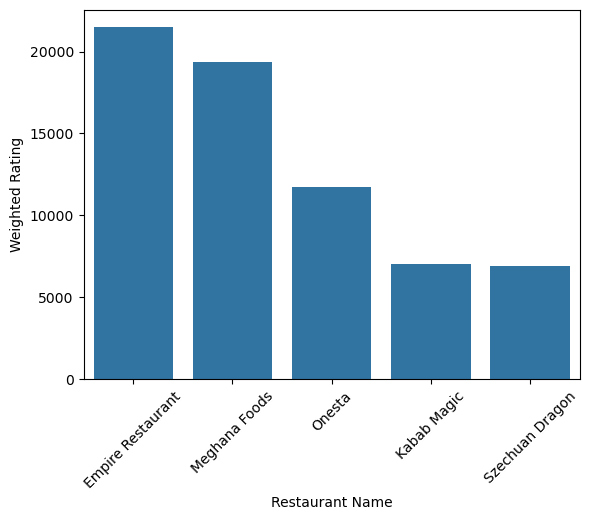

In [14]:
sns.barplot(data=Top5,x="name",y="weighted_rating")
plt.xlabel("Restaurant Name")
plt.ylabel("Weighted Rating")
plt.xticks(rotation=45)
plt.show()

### Conclusion:
**The Empire Restaurant is the most rated restaurant based on weighted rating followed by Meghana Foods,Onesta,Kabab Magic and Szechuan Dragon**

# Rating Distribution

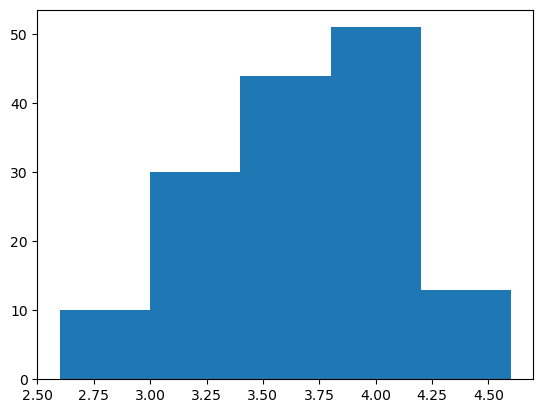

In [15]:
plt.hist(df1["rate"],bins=5)
plt.show()

### Conclusion:
**Majority of restaurants received rating between 3.5 to 4**

# Approximate Cost for Couples

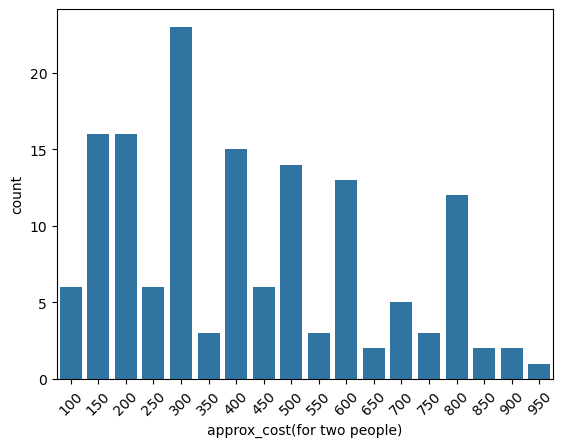

In [16]:
sns.countplot(x=df1["approx_cost(for two people)"])
plt.xticks(rotation=45)
plt.show()

### Conclusion:
**The majority of couples choose restaurants with an approximate cost of 300 rupees.**

# Ratings for Online and Offline Order

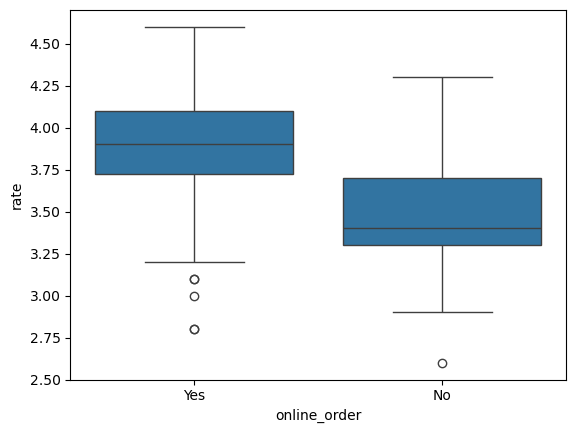

In [17]:
sns.boxplot(x="online_order",y="rate",data=df1)
plt.show()

### Conclusion:
**Offline orders received lower ratings compared to online orders which obtained excellent ratings**

# Order Mode Preferences by Restaurant Type

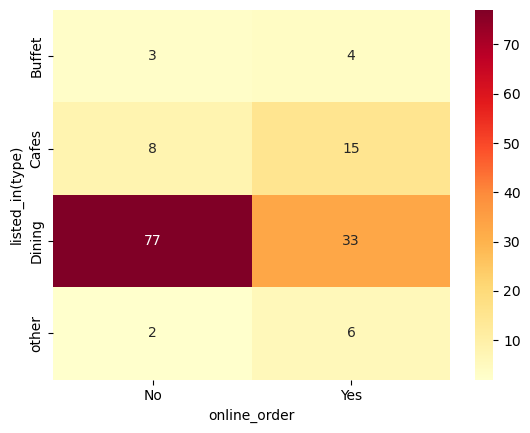

In [18]:
pivot_=df.pivot_table(index="listed_in(type)",columns="online_order", aggfunc="size",fill_value=0)
sns.heatmap(pivot_,annot=True,cmap="YlOrRd",fmt='d')
plt.show()

### Conclusion:
**Dining restaurants form the largest segment of the dataset and predominantly operate without online ordering. Cafes show a higher preference toward supporting online orders, shows a operational trend difference between dining and cafe formats**